In [ ]:
#Bibliotecas

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Função sinal

def sign(z):
  return np.where(z >= 0.5, 1.0, 0.0)


In [ ]:
# Ativação linear

def ativacao_linear(z):
  return z

In [ ]:
def treinar_adaline(X, d, eta=0.0005, tol=1e-6, epocas=1000):
    n_amostras, n_atributos = X.shape

    # 1. Inicialização com valores pequenos (ou zeros)
    w = np.random.randn(n_atributos) * 0.01
    b = np.random.randn() * 0.01

    historico_custo = []

    for epoca in range(epocas):
        custo_amostra = []

        indices = np.random.permutation(n_amostras)

        for i in indices:
            x_i = X[i]

            z = np.dot(x_i, w) + b
            y_linear = ativacao_linear(z)

            erro = d[i] - y_linear

            # Regra do Delta
            w += eta * erro * x_i
            b += eta * erro

            custo_amostra.append((erro**2) / 2)

        custo = np.sum(custo_amostra)
        historico_custo.append(custo)

        # 2. Critério de parada baseado na variação do custo
        if epoca > 0 and abs(historico_custo[-2] - historico_custo[-1]) < tol:
            print(f"Convergiu na época {epoca + 1}! Custo = {custo:.6f}")
            break

    return w, b, historico_custo

In [ ]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


In [ ]:
dados=load_iris()

print(dados.feature_names)
print(dados.target)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [ ]:
setosa_versicolor = (dados.target == 0) | (dados.target == 1)
X = dados.data[setosa_versicolor,2:]
y = dados.target[setosa_versicolor]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42,stratify=y)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
w, b, historico_custo = treinar_adaline(x_train, y_train)

Convergiu na época 275! Custo = 0.352158


In [ ]:
print(f"Pesos finais: {w}")
print(f"Bias final: {b}")
print(f"Número de épocas até convergir: {len(historico_custo)}")
print(f"Custo final: {historico_custo[-1]:.6f}")

Pesos finais: [0.26114438 0.22705281]
Bias final: 0.4994698751391529
Número de épocas até convergir: 275
Custo final: 0.352158


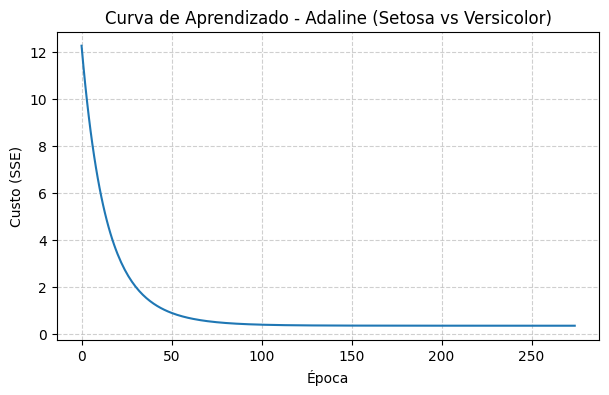

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(historico_custo)
plt.xlabel("Época")
plt.ylabel("Custo (SSE)")
plt.title("Curva de Aprendizado - Adaline (Setosa vs Versicolor)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
# Testando no conjunto de teste

z_teste = np.dot(x_test, w) + b
y_pred = sign(z_teste)
print(f"Acurácia no conjunto de teste: {np.mean(y_pred == y_test)}")

Acurácia no conjunto de teste: 1.0


Convergiu na época 313! Custo = 0.351068


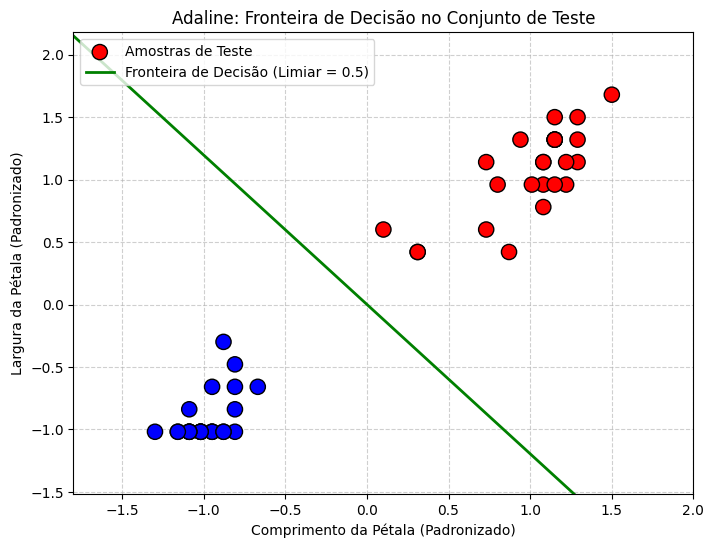

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Garanta que o treinamento use x_train e y_train
w, b, historico_custo = treinar_adaline(x_train, y_train)

# 2. Defina o intervalo de x1 com base nos dados padronizados de teste (x_test)
x1_min, x1_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
x1_vals = np.linspace(x1_min, x1_max, 100)

# 3. Cálculo da fronteira considerando limiar = 0.5:
# w1*x1 + w2*x2 + b = 0.5  =>  x2 = (0.5 - b - w1*x1) / w2
if w[1] != 0:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
else:
    x2_vals = np.zeros_like(x1_vals)

# 4. Plot dos dados de teste PADRONIZADOS
plt.figure(figsize=(8, 6))

plt.scatter(
    x_test[:, 0],
    x_test[:, 1],
    c=y_test,          # Usando y_test correto
    cmap="bwr",
    edgecolors="k",
    s=120,
    zorder=3,
    label="Amostras de Teste"
)

plt.plot(
    x1_vals,
    x2_vals,
    "g-",
    linewidth=2,
    label="Fronteira de Decisão (Limiar = 0.5)",
    zorder=2,
)

# Ajuste automático dos limites do gráfico para a escala padronizada
plt.xlim(x1_min, x1_max)
plt.ylim(x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5)

plt.xlabel("Comprimento da Pétala (Padronizado)")
plt.ylabel("Largura da Pétala (Padronizado)")
plt.legend(loc="upper left")
plt.title("Adaline: Fronteira de Decisão no Conjunto de Teste")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()